In [ ]:
import os
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import streamlit as st
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [2]:
from pathlib import Path

file_path = Path("/workspaces/Employee-Attrition-Prediction-and-Risk-Scoring-System-Machine-Learning-Based/data/Palo Alto Networks.csv")

# Reading the dataset
df = pd.read_csv(file_path, encoding='latin-1')

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [3]:
print(df.shape)
print(df.head())

(1470, 31)
   Age  Attrition     BusinessTravel  DailyRate              Department  \
0   41          1      Travel_Rarely       1102                   Sales   
1   49          0  Travel_Frequently        279  Research & Development   
2   37          1      Travel_Rarely       1373  Research & Development   
3   33          0  Travel_Frequently       1392  Research & Development   
4   27          0      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EnvironmentSatisfaction  \
0                 1          2  Life Sciences                        2   
1                 8          1  Life Sciences                        3   
2                 2          2          Other                        4   
3                 3          4  Life Sciences                        4   
4                 2          1        Medical                        1   

   Gender  ...  PerformanceRating  RelationshipSatisfaction  StockOptionLevel  \
0  Female  .

In [4]:
print("Shape:", df.shape)

df.head()

df.tail()

df.info()

Shape: (1470, 31)
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EnvironmentSatisfaction   1470 non-null   int64
 9   Gender                    1470 non-null   str  
 10  HourlyRate                1470 non-null   int64
 11  JobInvolvement            1470 non-null   int64
 12  JobLevel                  1470 non-null   int64
 13  JobRole                   1470 non-null   str  
 14  JobSatisfaction           1470 no

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
Attrition,1470.0,0.161224,0.367863,0.0,0.0,0.0,0.00,1.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.00,4.0


In [6]:
df.describe(include='str').T


,count,unique,top,freq
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
OverTime,1470,2,No,1054


In [7]:
df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [8]:
(df["Attrition"]
 .value_counts(normalize=True)*100)

Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64

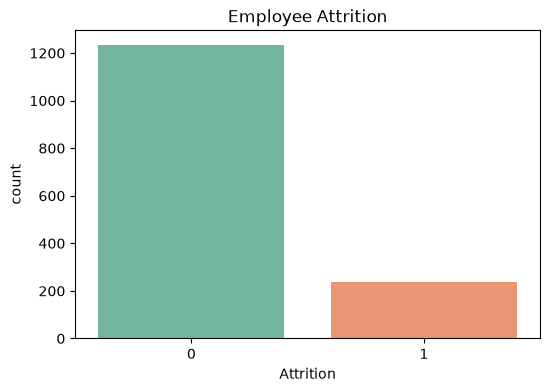

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x="Attrition", hue="Attrition", data=df, palette="Set2", legend=False)

plt.title("Employee Attrition")
plt.show()


In [10]:
print(df['Attrition'].value_counts())
print(df['Attrition'].value_counts(normalize=True) * 100)



Attrition
0    1233
1     237
Name: count, dtype: int64
Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64


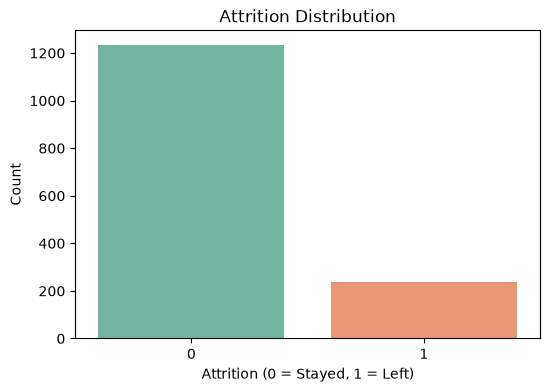

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', hue='Attrition', data=df, palette='Set2', legend=False)
plt.title('Attrition Distribution')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Count')
plt.show()


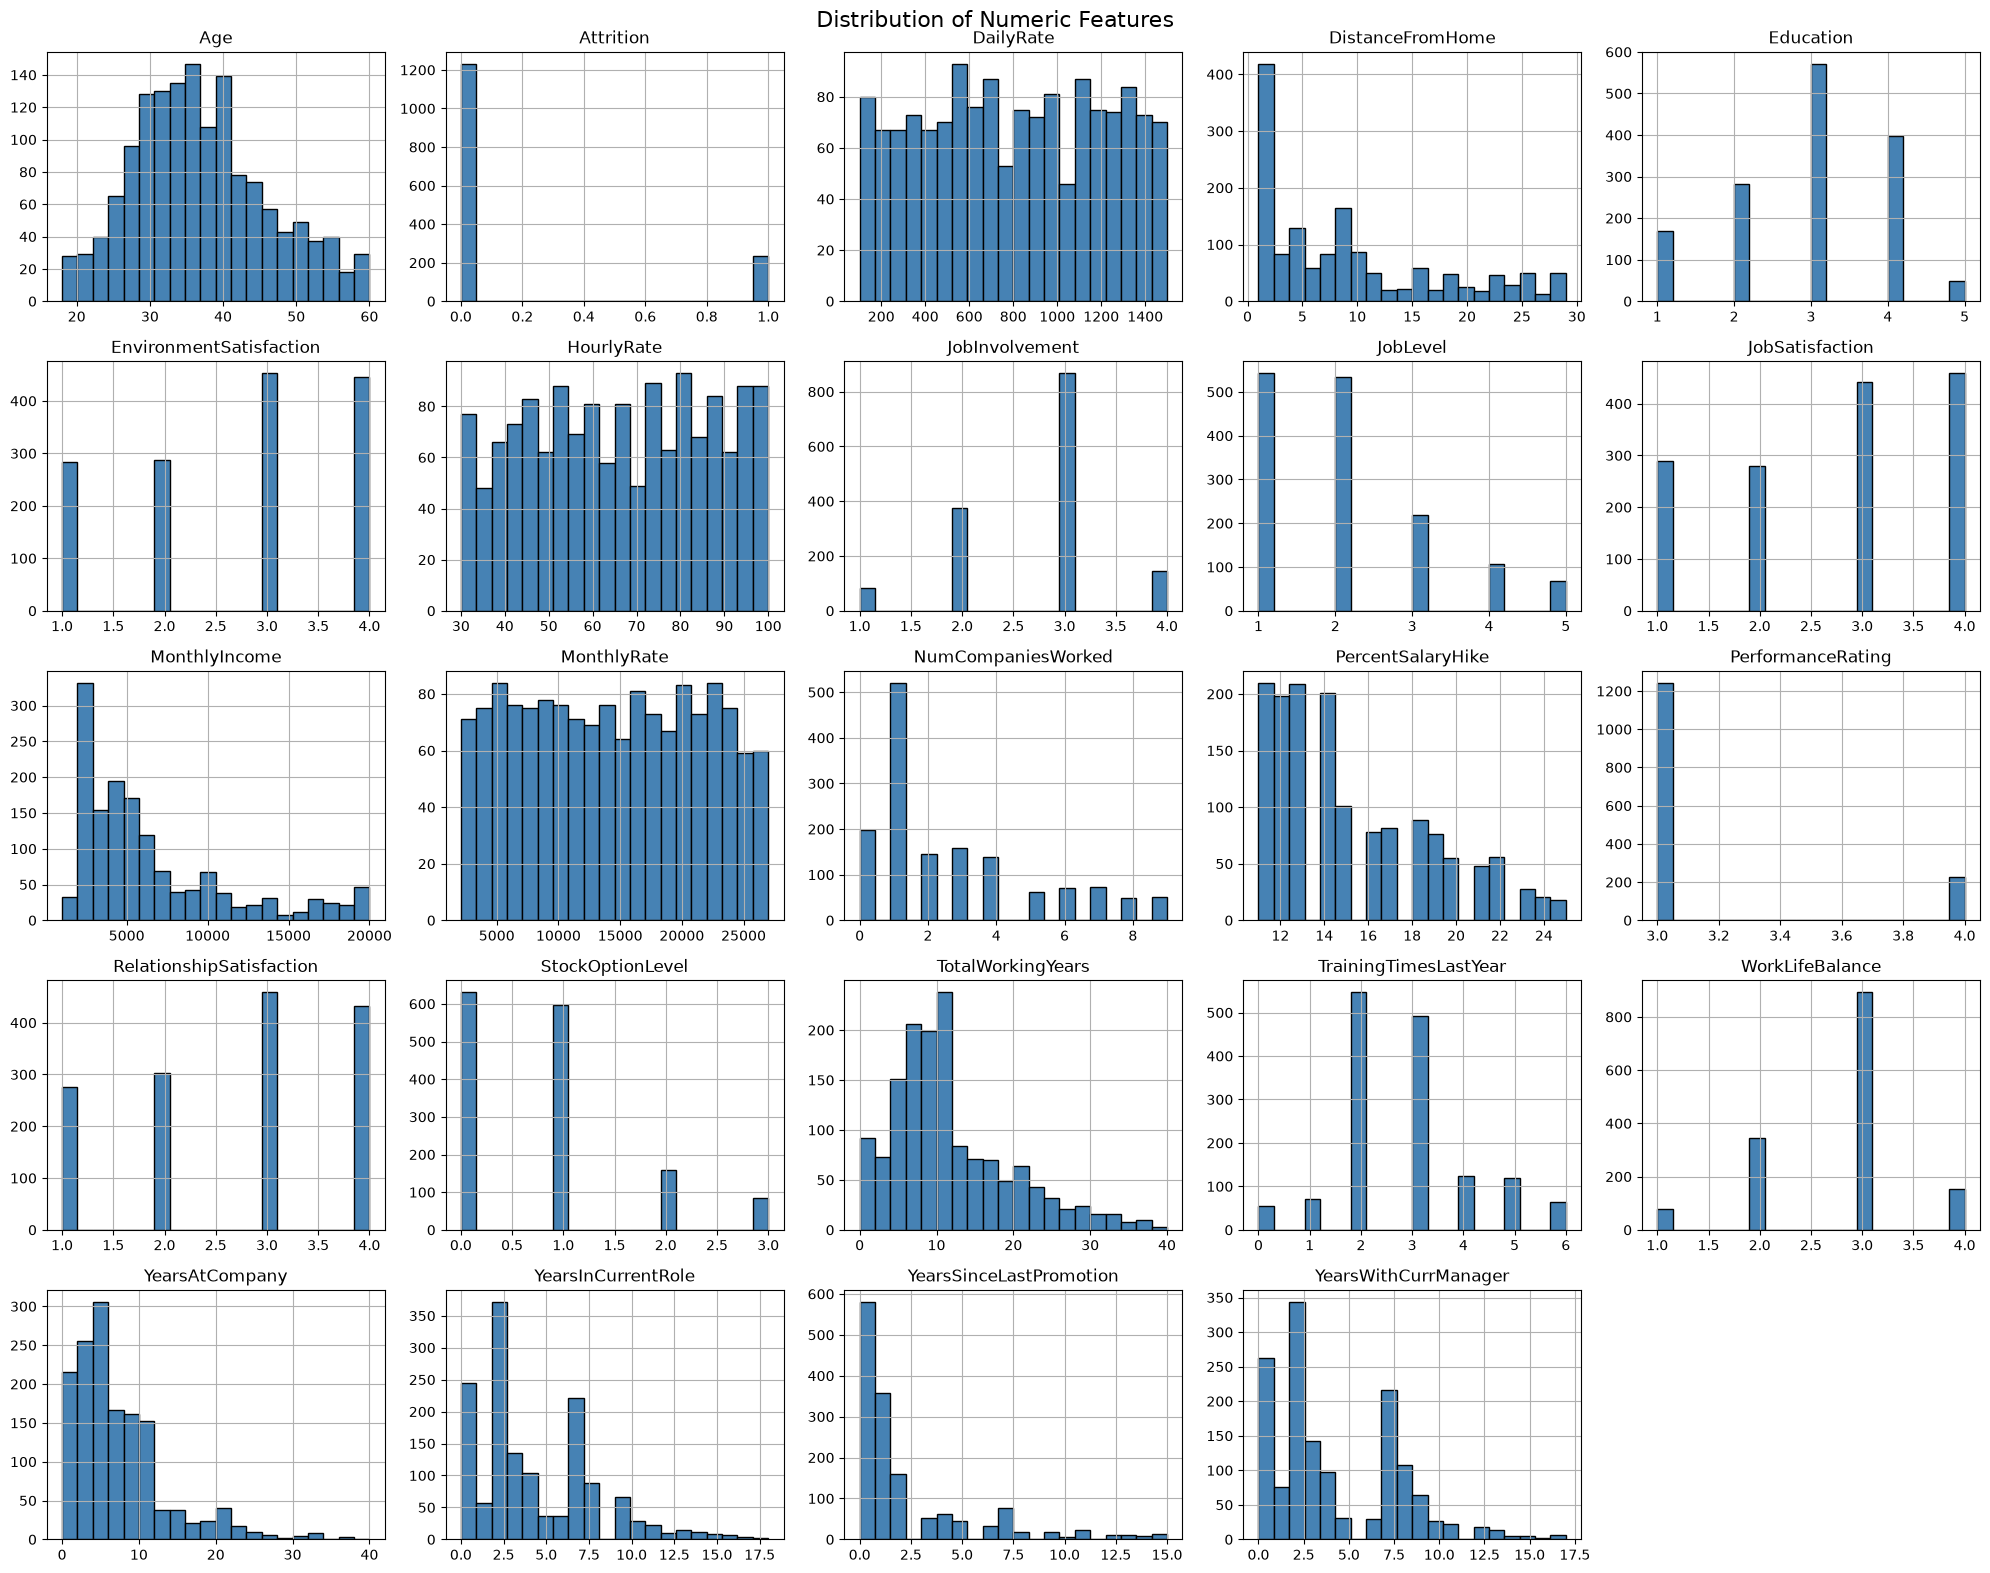

In [12]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols].hist(figsize=(20, 16), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Distribution of Numeric Features', fontsize=16)
plt.tight_layout()
plt.show()


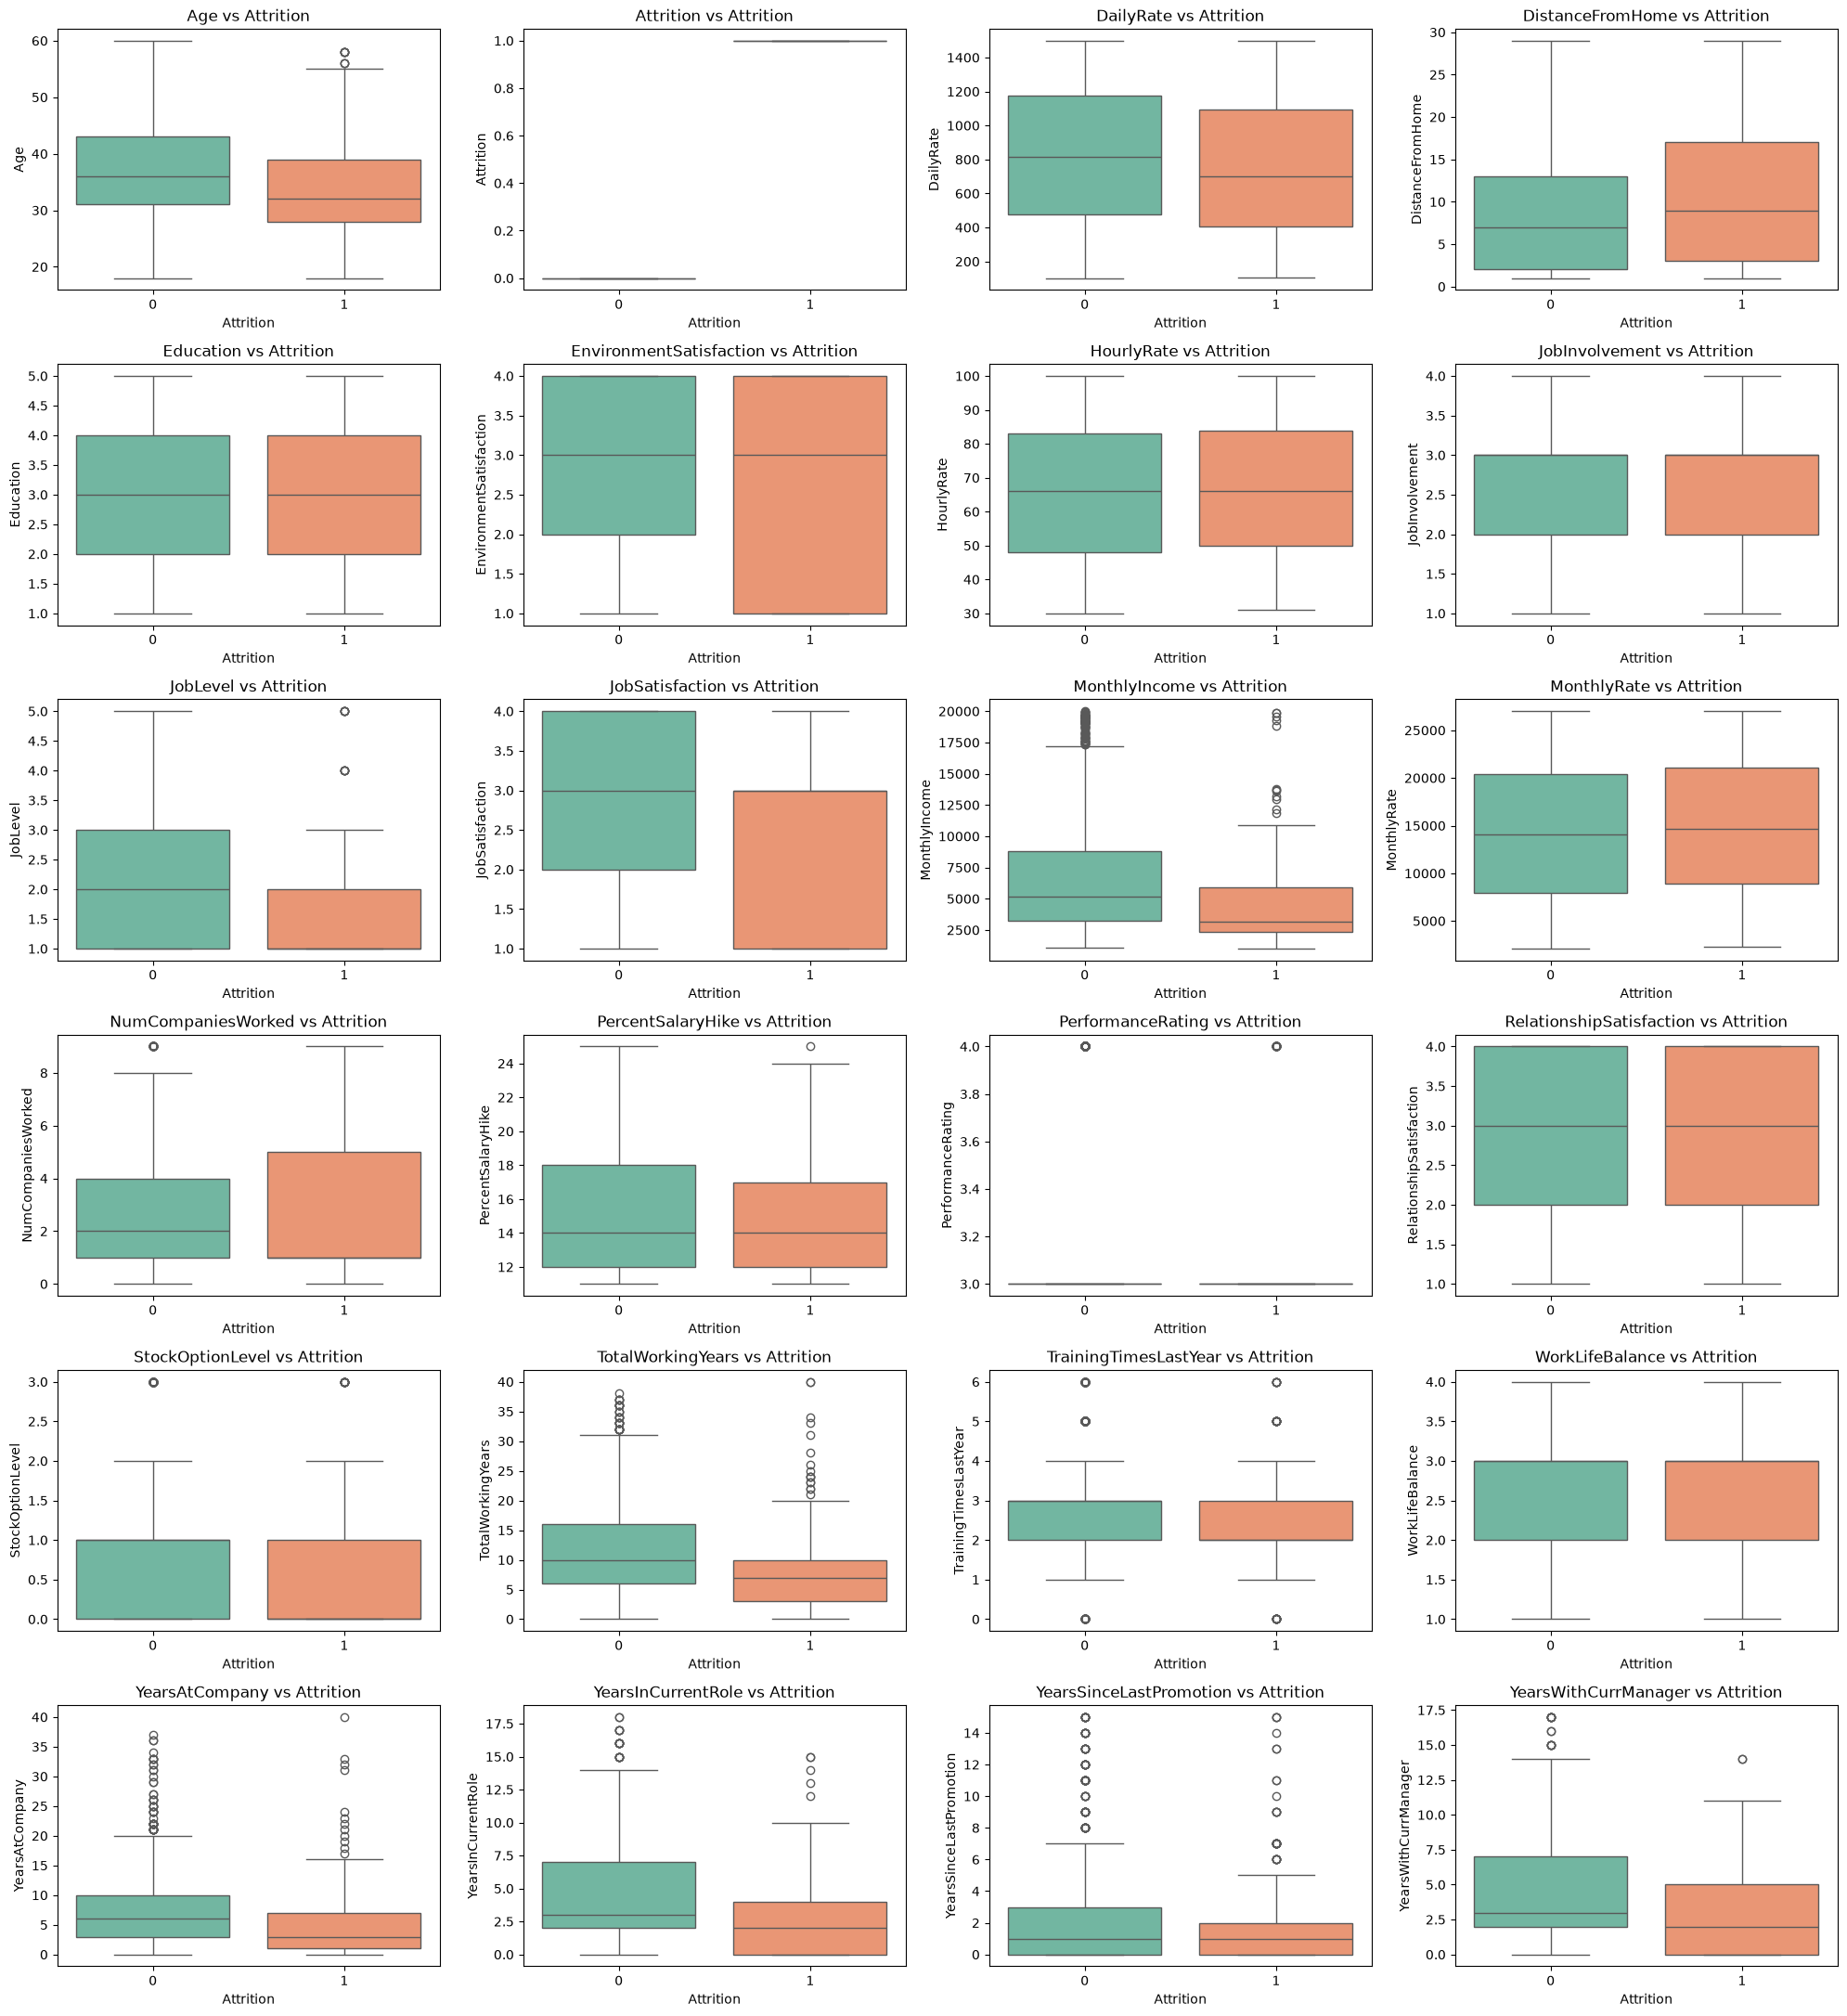

In [13]:
plt.figure(figsize=(20, 25))
for i, col in enumerate(num_cols, 1):
    plt.subplot(7, 4, i)
    sns.boxplot(x='Attrition', y=col, hue='Attrition', data=df, palette='Set2', legend=False)
    plt.title(f'{col} vs Attrition')
plt.tight_layout()
plt.show()


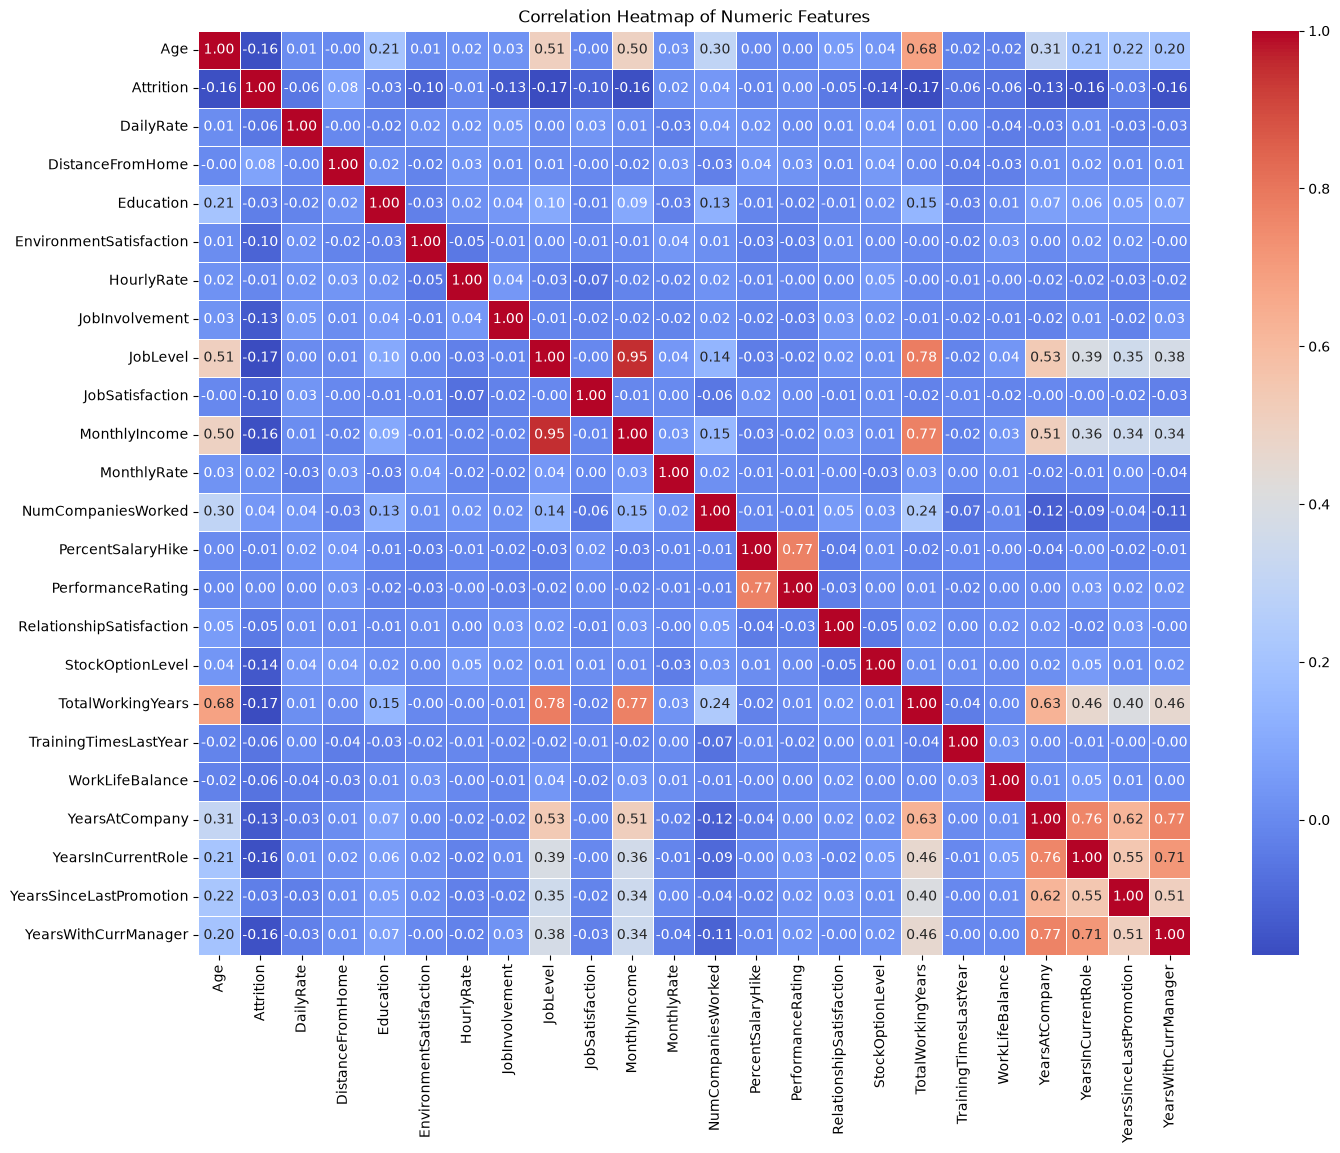

In [14]:
plt.figure(figsize=(16, 12))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

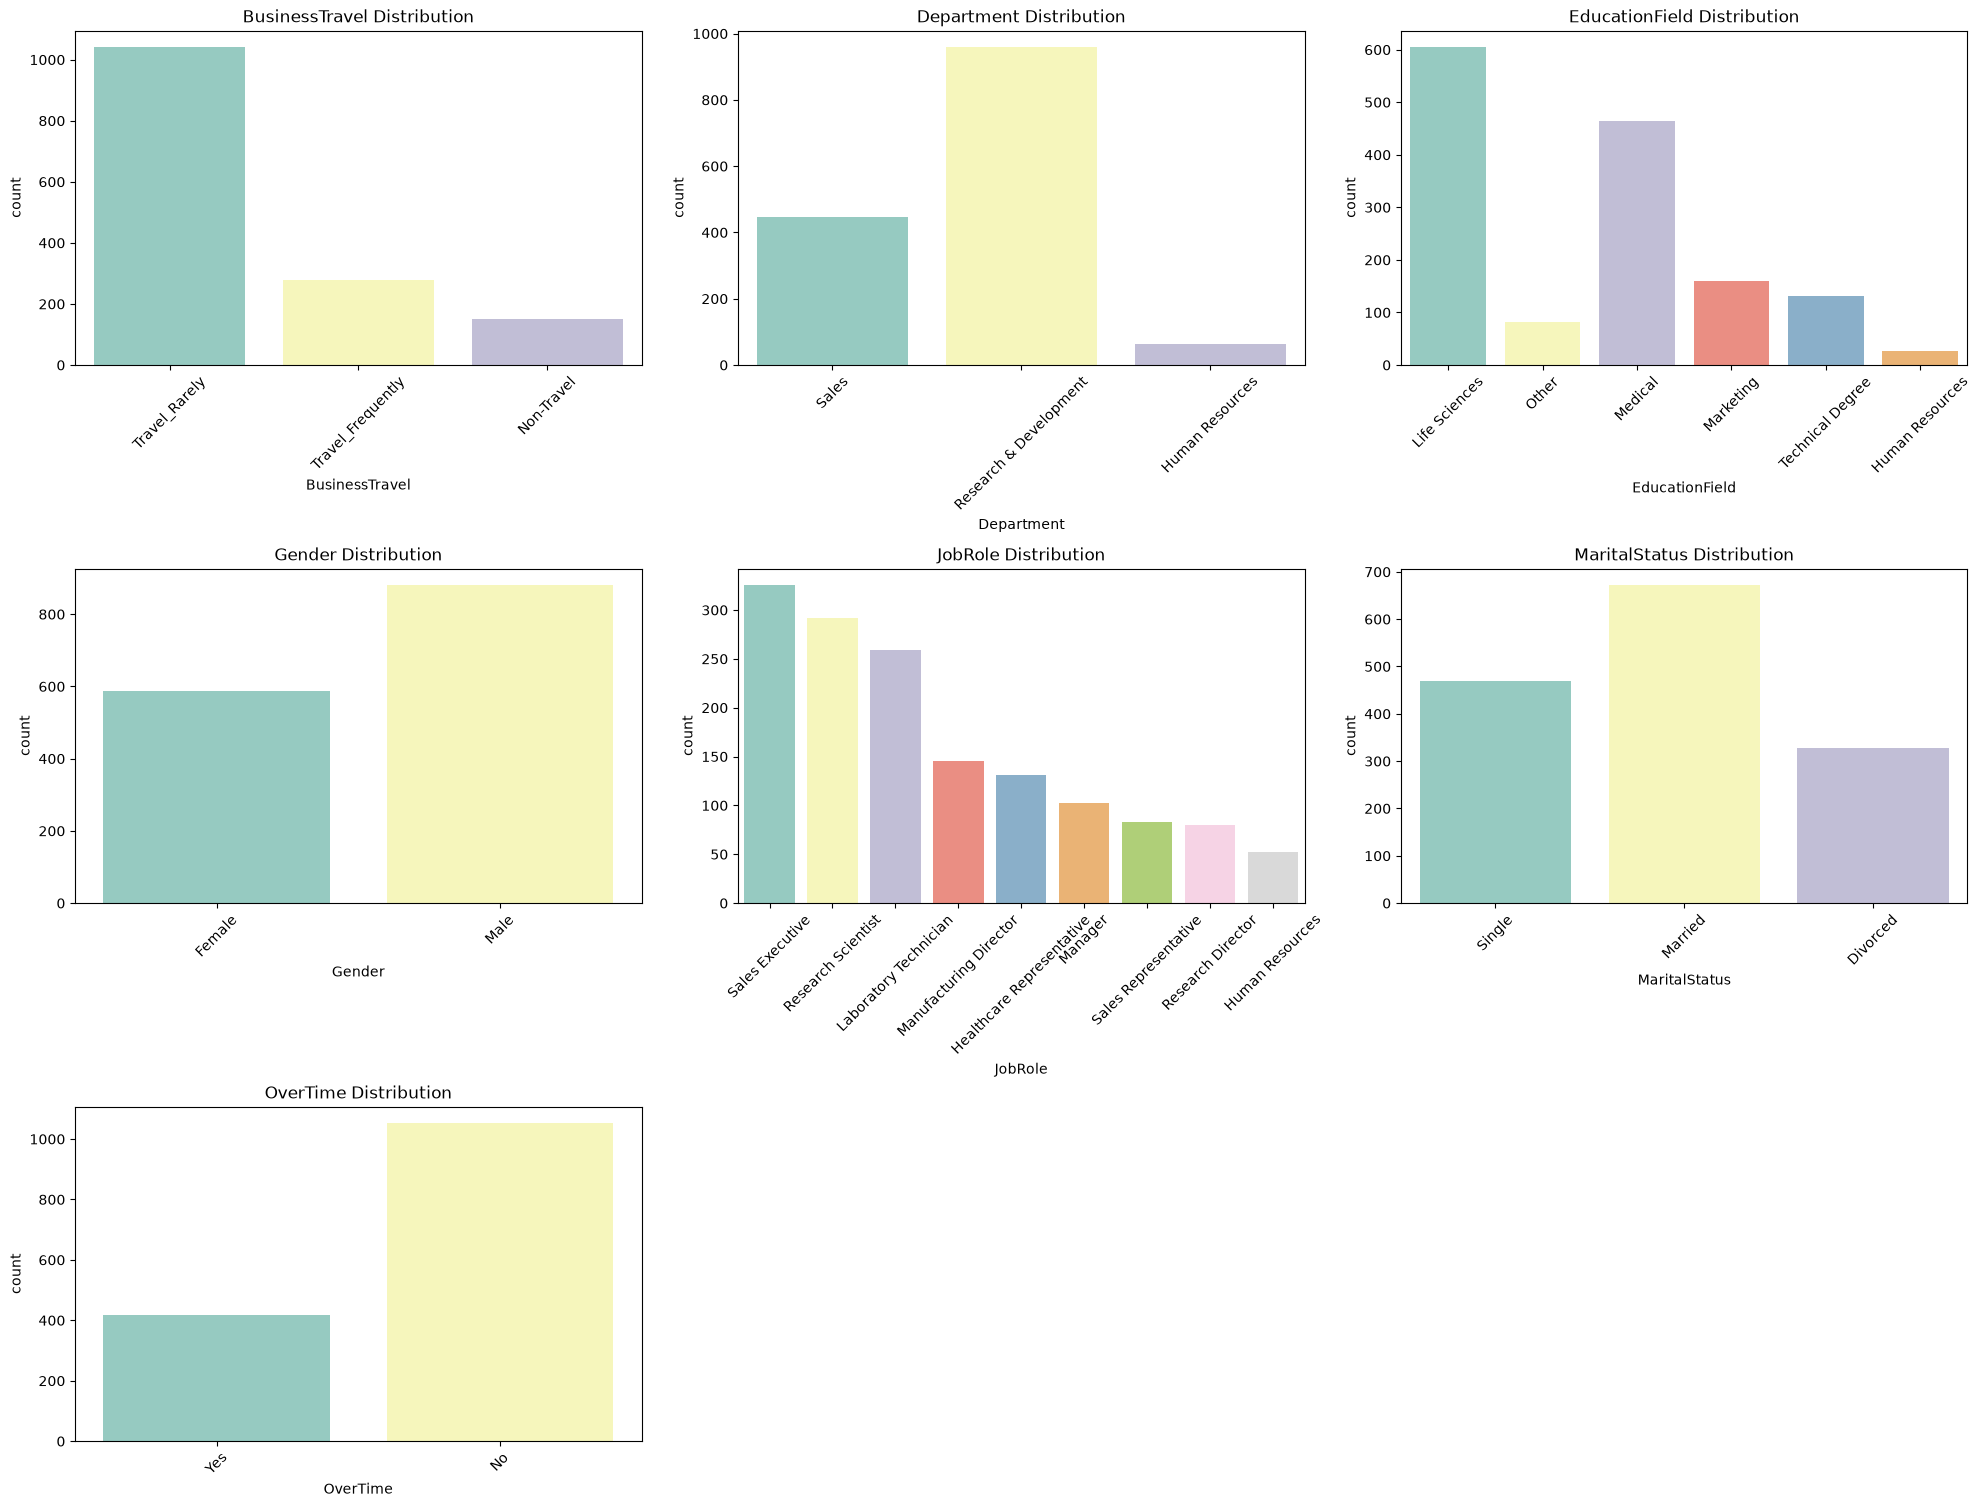

In [15]:
cat_cols = df.select_dtypes(include='str').columns.drop('Attrition', errors='ignore')

plt.figure(figsize=(20, 20))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(4, 3, i)
    sns.countplot(x=col, hue=col, data=df, palette='Set3', legend=False)
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


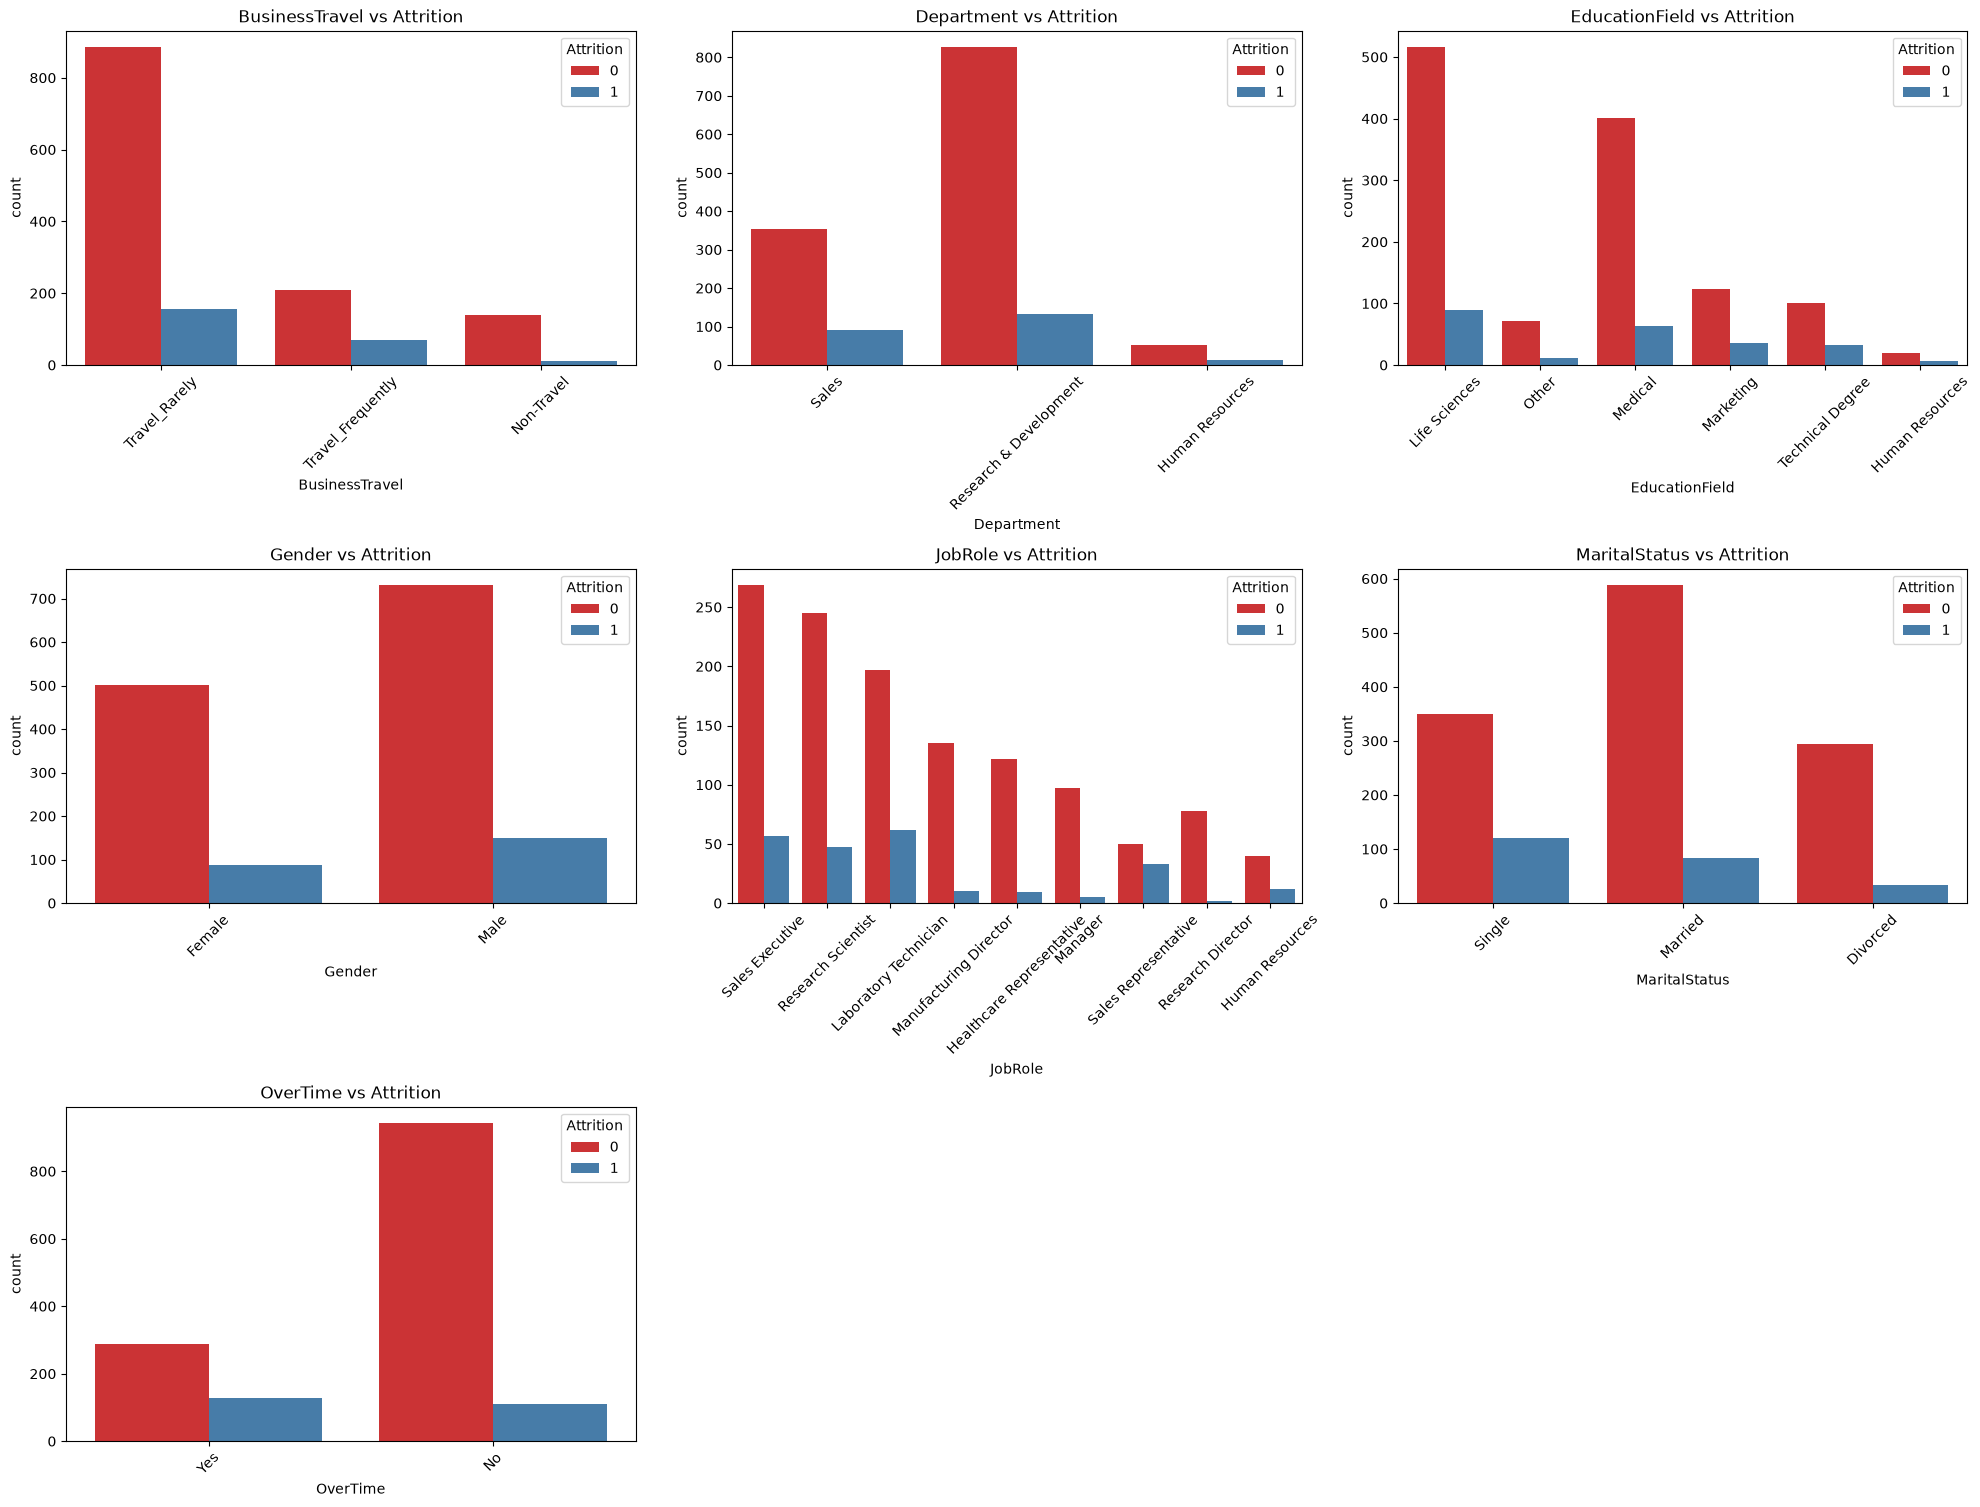

In [16]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(4, 3, i)
    sns.countplot(x=col, hue='Attrition', data=df, palette='Set1')
    plt.title(f'{col} vs Attrition')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


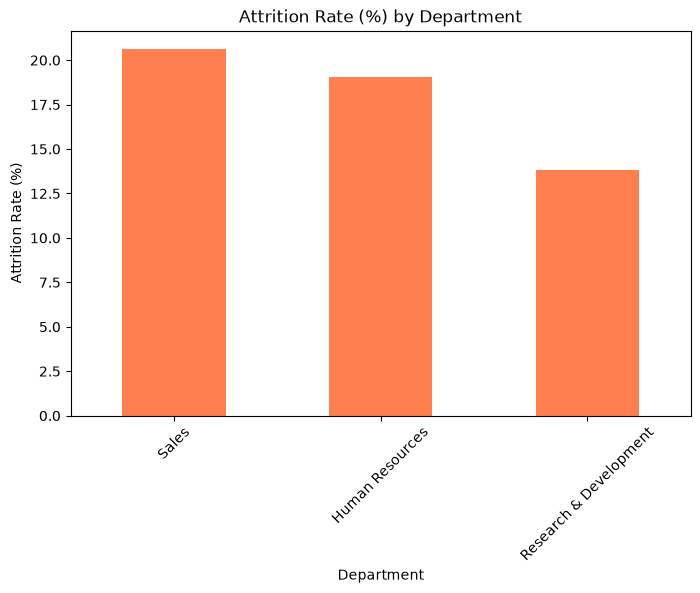

In [17]:
dept_attrition = df.groupby('Department')['Attrition'].mean() * 100
plt.figure(figsize=(8, 5))
dept_attrition.sort_values(ascending=False).plot(kind='bar', color='coral')
plt.title('Attrition Rate (%) by Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
plt.show()


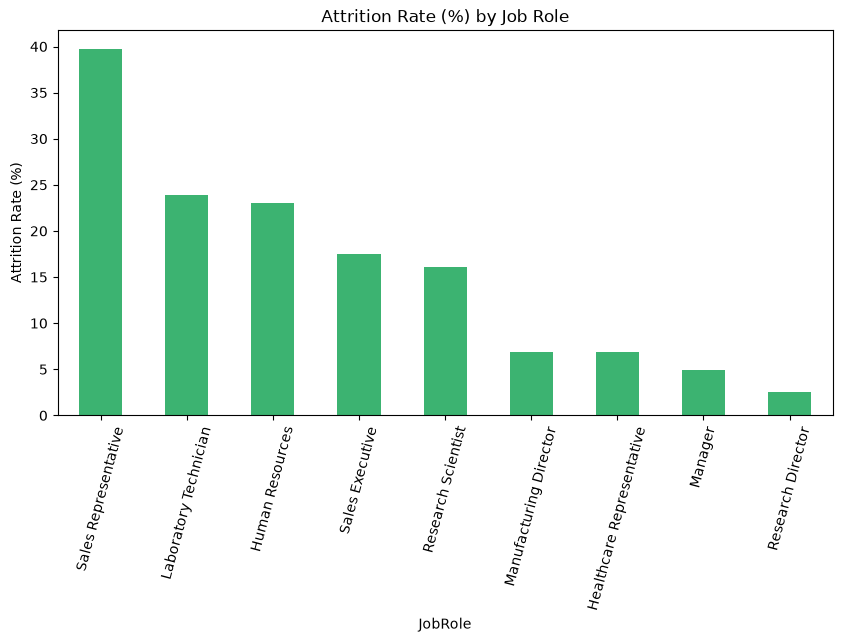

In [18]:
role_attrition = df.groupby('JobRole')['Attrition'].mean() * 100
plt.figure(figsize=(10, 5))
role_attrition.sort_values(ascending=False).plot(kind='bar', color='mediumseagreen')
plt.title('Attrition Rate (%) by Job Role')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=75)
plt.show()


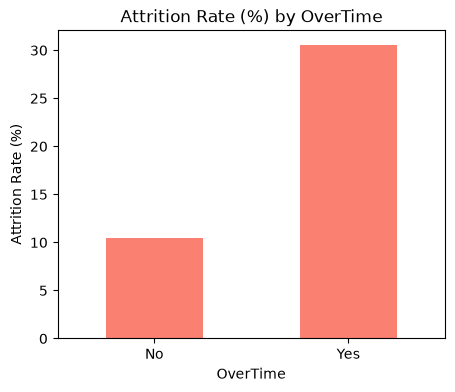

In [19]:
overtime_attrition = df.groupby('OverTime')['Attrition'].mean() * 100
plt.figure(figsize=(5, 4))
overtime_attrition.plot(kind='bar', color='salmon')
plt.title('Attrition Rate (%) by OverTime')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.show()


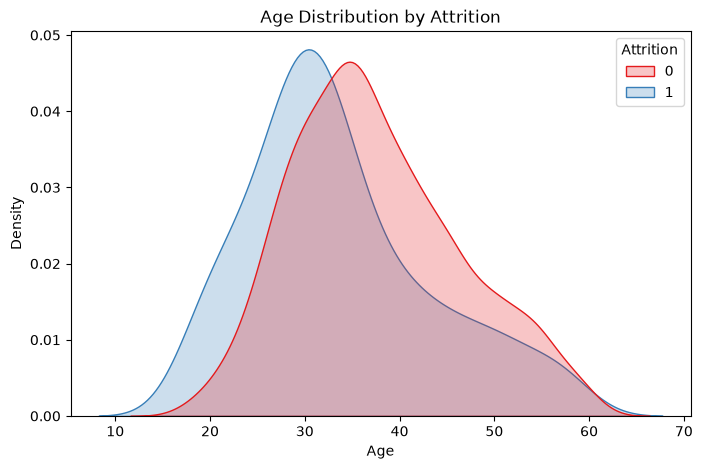

In [20]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='Age', hue='Attrition', fill=True, common_norm=False, palette='Set1')
plt.title('Age Distribution by Attrition')
plt.show()

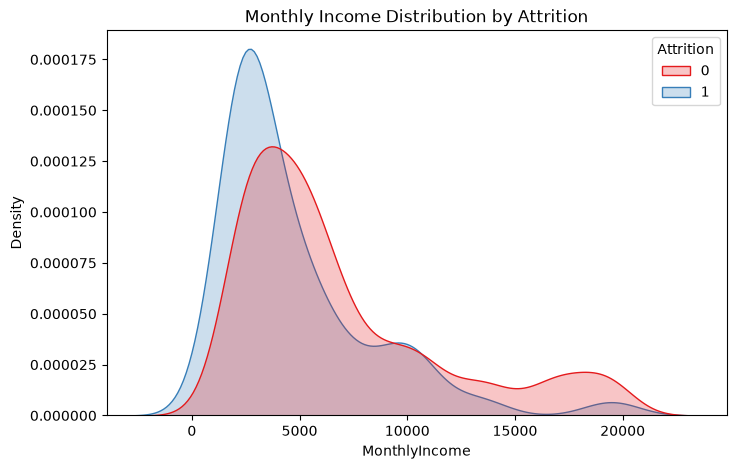

In [21]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='MonthlyIncome', hue='Attrition', fill=True, common_norm=False, palette='Set1')
plt.title('Monthly Income Distribution by Attrition')
plt.show()

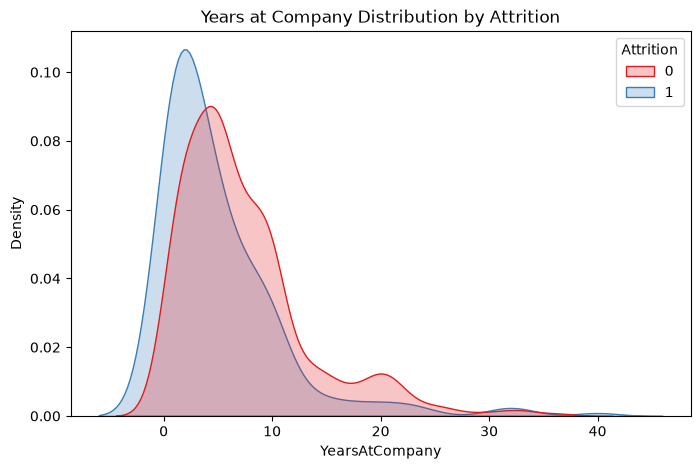

In [22]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='YearsAtCompany', hue='Attrition', fill=True, common_norm=False, palette='Set1')
plt.title('Years at Company Distribution by Attrition')
plt.show()

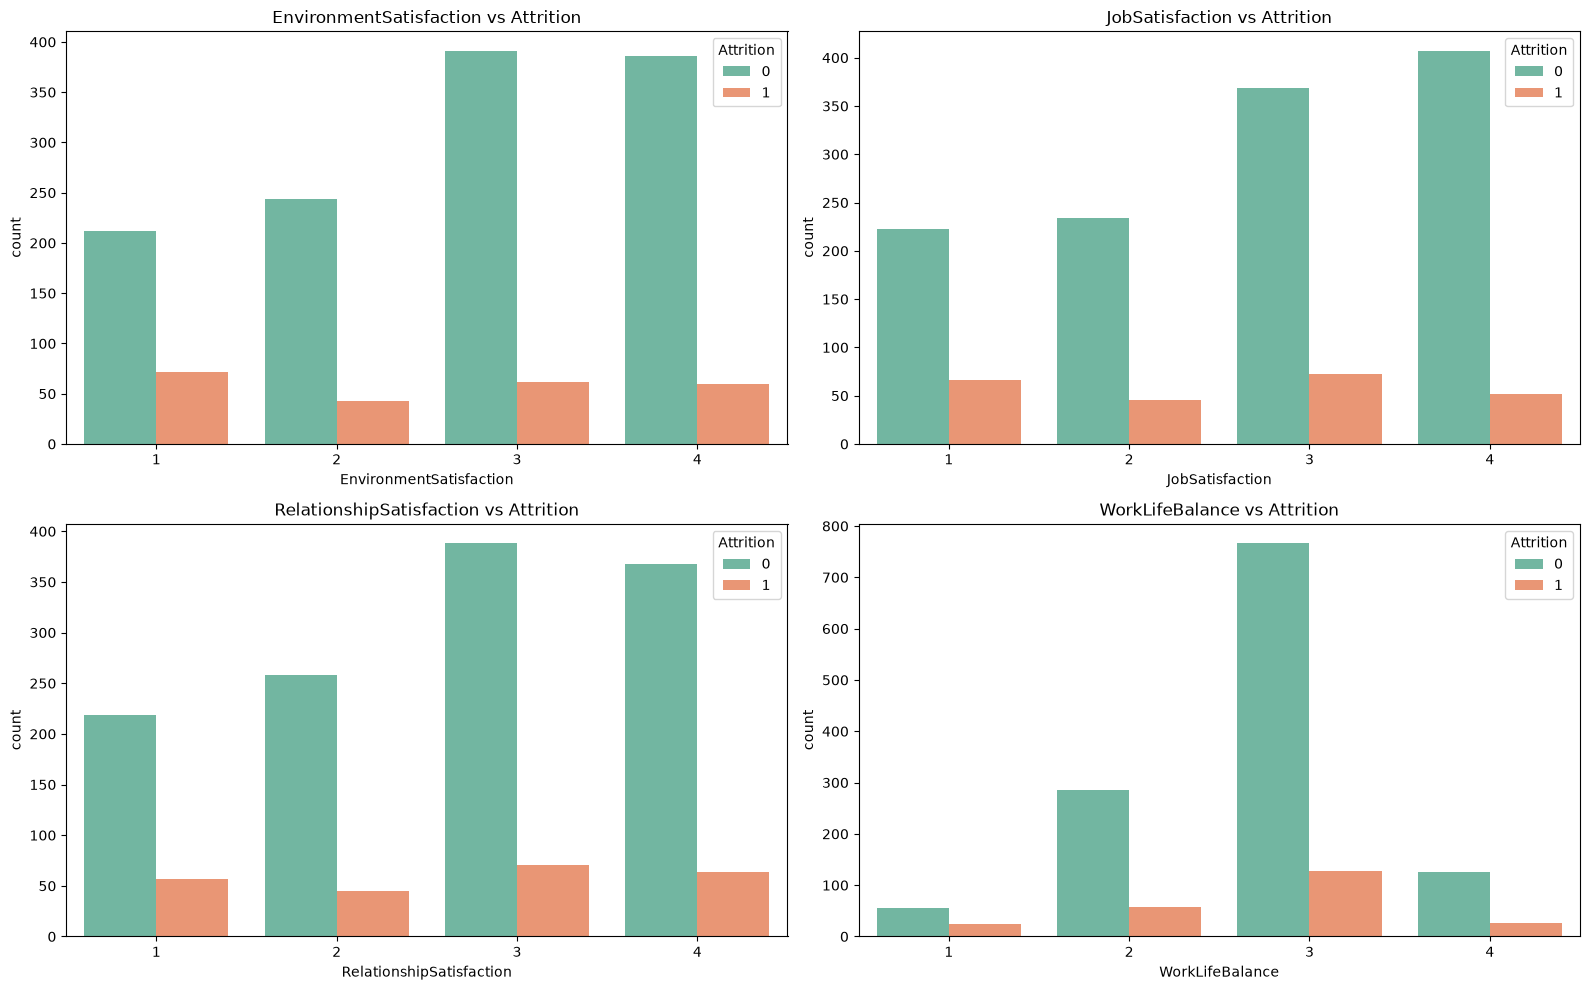

In [23]:
satisfaction_cols = ['EnvironmentSatisfaction', 'JobSatisfaction',
                      'RelationshipSatisfaction', 'WorkLifeBalance']

plt.figure(figsize=(16, 10))
for i, col in enumerate(satisfaction_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=col, hue='Attrition', data=df, palette='Set2')
    plt.title(f'{col} vs Attrition')
plt.tight_layout()
plt.show()

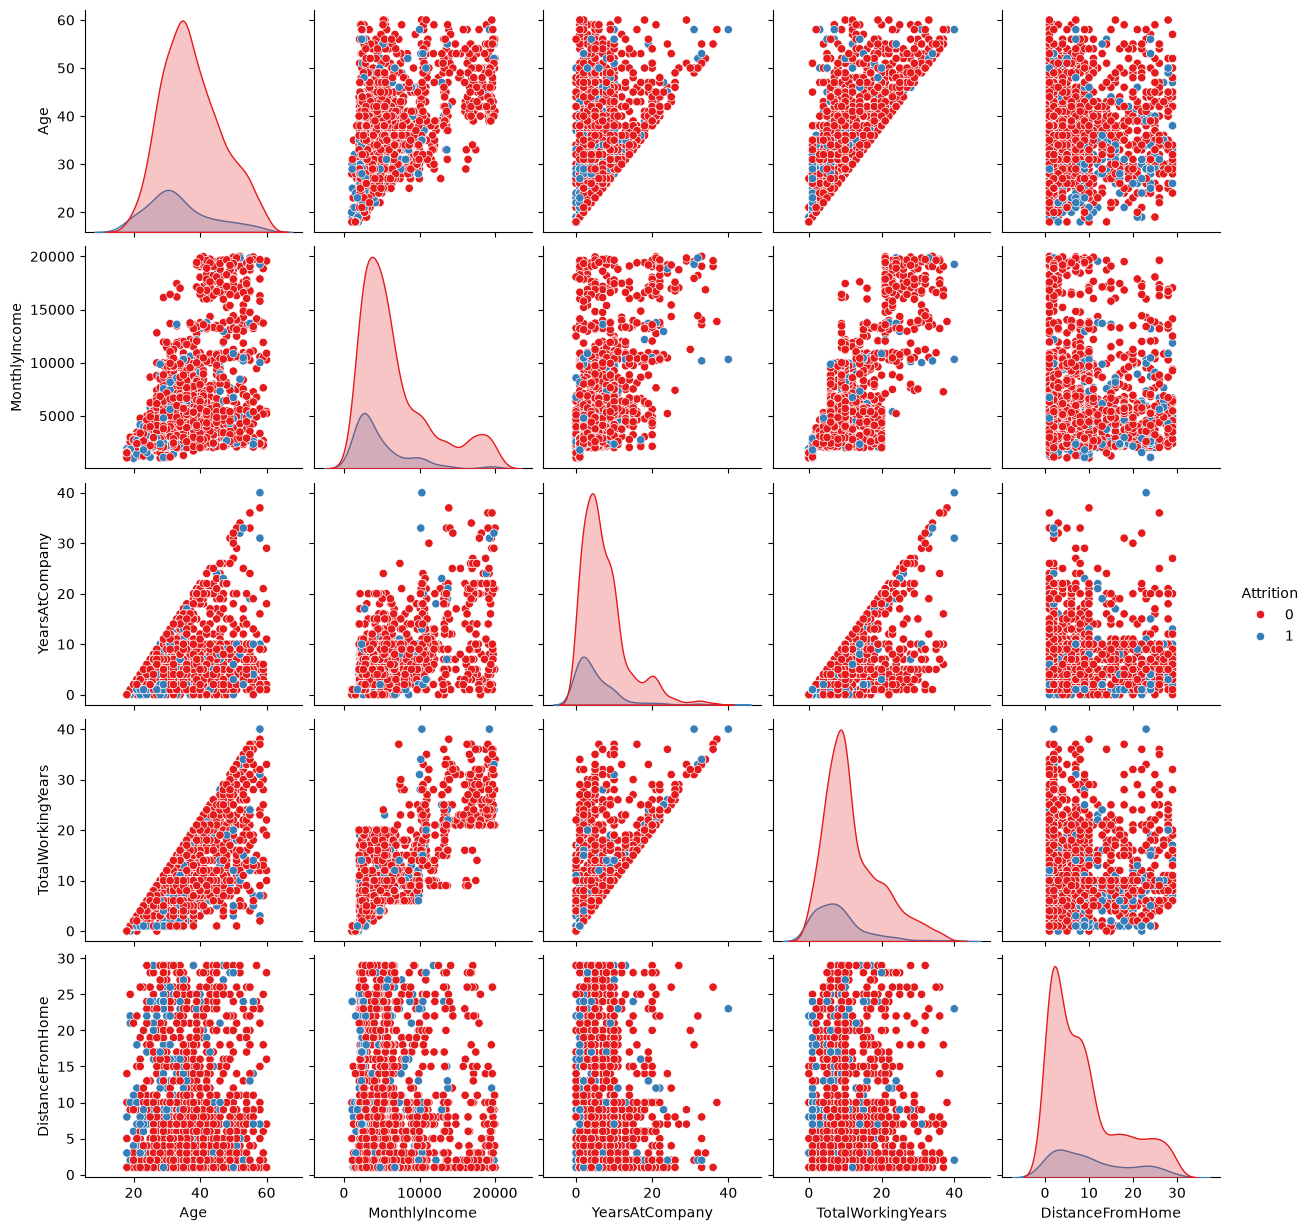

In [24]:
key_features = ['Age', 'MonthlyIncome', 'YearsAtCompany',
                 'TotalWorkingYears', 'DistanceFromHome', 'Attrition']
sns.pairplot(df[key_features], hue='Attrition', palette='Set1', diag_kind='kde')
plt.show()

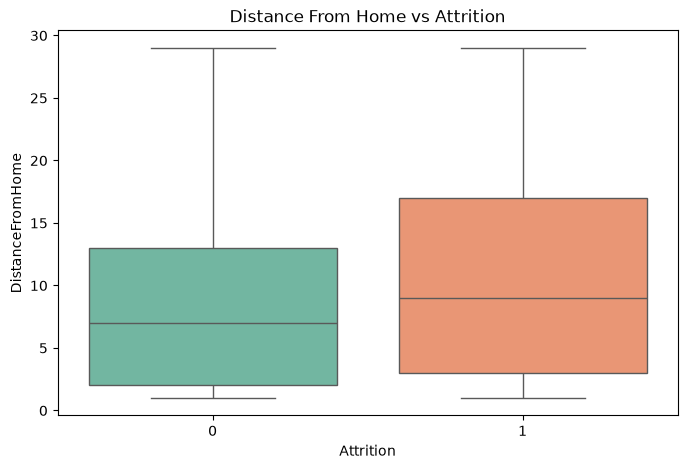

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Attrition', y='DistanceFromHome', hue='Attrition', data=df, palette='Set2', legend=False)
plt.title('Distance From Home vs Attrition')
plt.show()


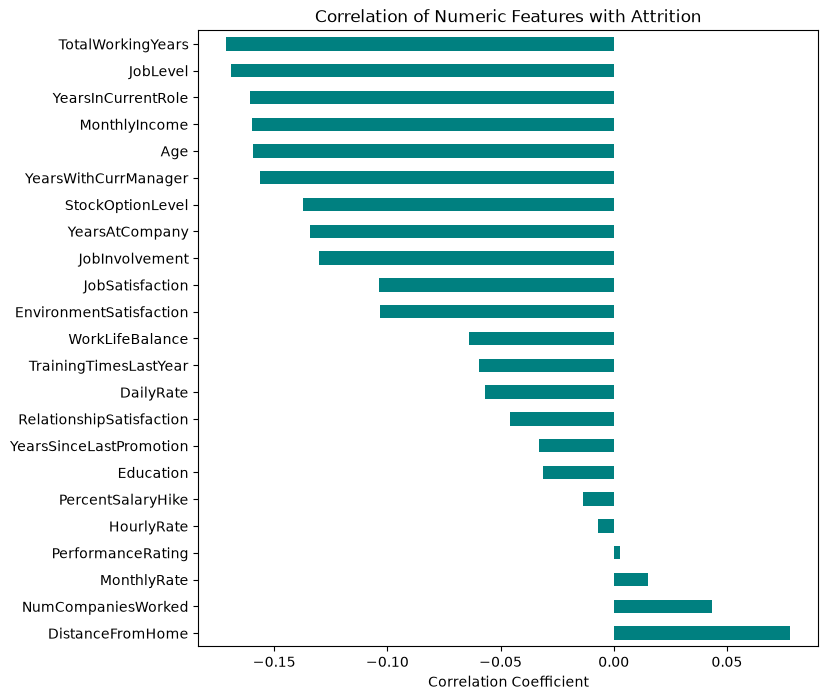

In [26]:
attrition_corr = df[num_cols].corr()['Attrition'].sort_values(ascending=False)
plt.figure(figsize=(8, 8))
attrition_corr.drop('Attrition').plot(kind='barh', color='teal')
plt.title('Correlation of Numeric Features with Attrition')
plt.xlabel('Correlation Coefficient')
plt.show()